# Plot PyLLMPatch Instruction Distance Distributions

This notebook plots the distributions of `sum_instruction_distance` and `sum_code_object_normalized_instruction_distance` from `pyllmpatch_semantic_error_distance.csv`.

Both plots are tightly zoomed so the main mass is visible and the long tail does not dominate. Outliers beyond the zoom range are shown sparsely as sampled markers at the right edge, together with an outlier count.

In [38]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

In [39]:
load_dotenv()

project_root = Path(os.getenv("PROJECT_ROOT_DIR"))
csv_path = project_root / "dataset" / "results" / "pyllmpatch_semantic_error_distance.csv"

df = pd.read_csv(csv_path)
df = df[df["status"] == "summary"].copy()
df = df.sort_values("file_hash").reset_index(drop=True)
df[["file_hash", "sum_instruction_distance", "sum_code_object_normalized_instruction_distance"]].head()

,file_hash,sum_instruction_distance,sum_code_object_normalized_instruction_distance
0,0003cc17c0694ad2a64411aa891571da06fa91039926de...,2.0,0.014706
1,000637e3672e0ec68d9852c2f5a5b8bdb0abea256c904b...,5.0,0.108696
2,000981a207911e3d469d4427beead4fc6d051a6c50d67d...,48.0,0.551724
3,000cf7e0066e10719b961131a79dde7ef8ba8ab195861c...,26.0,0.495383
4,0010438e4fa4dffbfbdb09adbd29d85c2cce65cd3c9be1...,50.0,1.000000


In [ ]:
def plot_zoomed_hist_with_normal(
    ax,
    values,
    title,
    xlabel,
    color,
    zoom_max=None,
    zoom_quantile=0.90,
    max_outlier_points=40,
):
    values = np.asarray(values, dtype=float)
    if zoom_max is None:
        zoom_max = float(np.quantile(values, zoom_quantile))

    in_range = values[values <= zoom_max]
    outliers = values[values > zoom_max]

    ax.hist(in_range, bins=30, density=True, color=color, alpha=0.65, edgecolor="black")
    ax.set_xlim(0, zoom_max)

    if len(in_range) > 1:
        mu = in_range.mean()
        sigma = in_range.std(ddof=0)
        if sigma > 0:
            xs = np.linspace(0, zoom_max, 300)
            ys = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
            ax.plot(xs, ys, color="black", linewidth=2, label=f"Normal fit in zoomed range: μ={mu:.3f}, σ={sigma:.3f}")

    if len(outliers) > 0:
        sample_count = min(len(outliers), max_outlier_points)
        ymax = ax.get_ylim()[1]
        y = np.full(sample_count, ymax * 0.05)
        x = np.full(sample_count, zoom_max)
        ax.scatter(x, y, color="red", s=18, alpha=0.6, marker="|", label=f"outliers > {zoom_max:.3f}: {len(outliers)}")
        ax.text(
            zoom_max * 0.98,
            ymax * 0.92,
            f"{len(outliers)} outliers > {zoom_max:.3f}",
            ha="right",
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.legend()

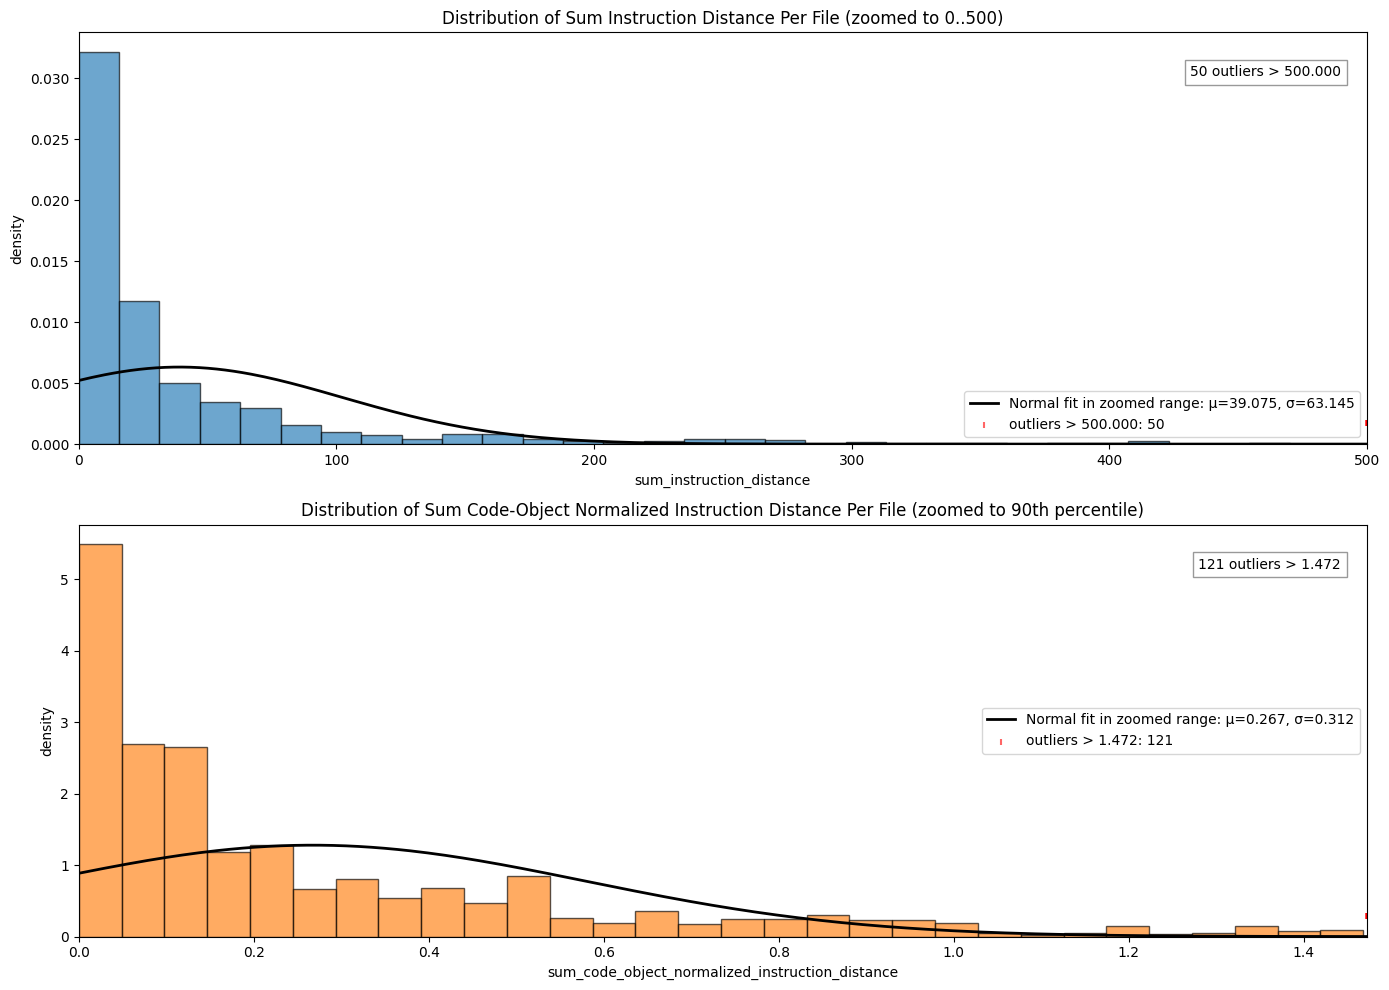

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_zoomed_hist_with_normal(
    axes[0],
    df["sum_instruction_distance"],
    "Distribution of Sum Instruction Distance Per File (zoomed to 0..500)",
    "sum_instruction_distance",
    "tab:blue",
    zoom_max=500,
)

plot_zoomed_hist_with_normal(
    axes[1],
    df["sum_code_object_normalized_instruction_distance"],
    "Distribution of Sum Code-Object Normalized Instruction Distance Per File (zoomed to 90th percentile)",
    "sum_code_object_normalized_instruction_distance",
    "tab:orange",
    zoom_max=None,
    zoom_quantile=0.90,
)

plt.tight_layout()
plt.show()